# 2D demo: Gaussian smoothing + first vs second derivatives

We build a synthetic 2D image with a **step edge** (optionally rotated) and optional noise.

We then apply Gaussian smoothing and compute:

## 1) First-order (Derivative-of-Gaussian)
Let
$$
L(x,y;\sigma) = (G_\sigma * I)(x,y)
$$
Then the gradient is
$$
\nabla L = (L_x, L_y).
$$

Because the 2D Gaussian is separable:
$$
G_\sigma(x,y)=g_\sigma(x)\,g_\sigma(y),
$$
we can compute derivatives using 1D kernels:
$$
L_x = (g'_\sigma \text{ in x}) * (g_\sigma \text{ in y}) * I,
\quad
L_y = (g_\sigma \text{ in x}) * (g'_\sigma \text{ in y}) * I.
$$

The scalar edge-strength map is:
$$
M = \|\nabla L\| = \sqrt{L_x^2 + L_y^2}.
$$
For a blurred step edge, **M forms a ridge**, and the ridge is strongest near the edge.

## 2) Second-order (Laplacian-of-Gaussian idea)
We compute second derivatives:
$$
L_{xx},\; L_{yy}
$$
and then the Laplacian:
$$
\nabla^2 L = L_{xx}+L_{yy}.
$$

For a clean step edge, the Laplacian typically has **positive/negative lobes** and a **zero-crossing** near the edge center.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_1d_kernels(sigma: float, radius_sigma: float = 4.0):
    """
    Returns discrete 1D kernels: g (Gaussian), g1 (first derivative), g2 (second derivative).
    We assume pixel spacing dx = 1 for simplicity.
    """
    assert sigma > 0
    r = int(np.ceil(radius_sigma * sigma))
    x = np.arange(-r, r + 1, dtype=float)

    g = np.exp(-(x**2) / (2 * sigma**2))
    g = g / g.sum()  # normalize so sum(g)=1

    # Derivatives of Gaussian (discrete samples of continuous formulas)
    g1 = -(x / (sigma**2)) * g
    g2 = ((x**2 - sigma**2) / (sigma**4)) * g

    return g, g1, g2

def convolve1d_axis(img: np.ndarray, k: np.ndarray, axis: int) -> np.ndarray:
    """
    1D convolution along one axis with 'same' size output.
    Uses reflect padding to avoid border artifacts (zero-padding would create
    a fake step edge at the border, producing spurious high gradient values).
    """
    pad = len(k) // 2

    def _conv(v: np.ndarray) -> np.ndarray:
        # "edge" = nearest-neighbor: repeats the border pixel outward.
        # No fake step is introduced at the border (unlike zero-padding),
        # and no mirror artifact (unlike reflect).
        v_pad = np.pad(v, pad, mode="edge")
        return np.convolve(v_pad, k, mode="valid")[:len(v)]

    return np.apply_along_axis(_conv, axis, img)

def separable_conv(img: np.ndarray, kx: np.ndarray, ky: np.ndarray) -> np.ndarray:
    """
    Separable convolution: first along x-axis (axis=1), then along y-axis (axis=0).
    """
    tmp = convolve1d_axis(img, kx, axis=1)
    out = convolve1d_axis(tmp, ky, axis=0)
    return out

def zero_crossings_4nbr(lap: np.ndarray) -> np.ndarray:
    """
    Simple 4-neighborhood zero-crossing detector for a scalar field 'lap'.
    Returns a boolean mask where sign changes occur between neighbors.
    """
    zc = np.zeros_like(lap, dtype=bool)
    # horizontal sign changes
    zc[:, 1:] |= (lap[:, 1:] * lap[:, :-1] < 0)
    # vertical sign changes
    zc[1:, :] |= (lap[1:, :] * lap[:-1, :] < 0)
    return zc

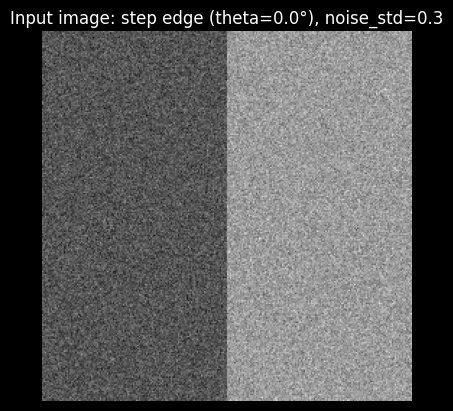

In [2]:
# -------------------------
# Parameters (edit these)
# -------------------------
H, W = 256, 256
A = 1.0
theta_deg = 0.0         # rotate the edge; start with 0.0 (vertical edge), try 30, 45, ...
noise_std = 0.3         # set to 0.0 for no noise; try 0.10
seed = 0
edge_thresh_ratio = 0.3 # fraction of M.max() used as threshold for both 1st and 2nd order

# Coordinate grid centered at 0
yy, xx = np.mgrid[0:H, 0:W]
x = xx - (W - 1) / 2
y = yy - (H - 1) / 2

theta = np.deg2rad(theta_deg)
# Signed distance to a line through the origin with normal n = (cos(theta), sin(theta))
d = x * np.cos(theta) + y * np.sin(theta)

# Step edge: one side 0, other side A
I_clean = A * (d >= 0).astype(float)



# Add noise
rng = np.random.default_rng(seed)
I = I_clean + rng.normal(0.0, noise_std, size=I_clean.shape)

plt.figure()
plt.imshow(I, cmap="gray")
plt.title(f"Input image: step edge (theta={theta_deg}°), noise_std={noise_std}")
plt.axis("off")
plt.show()

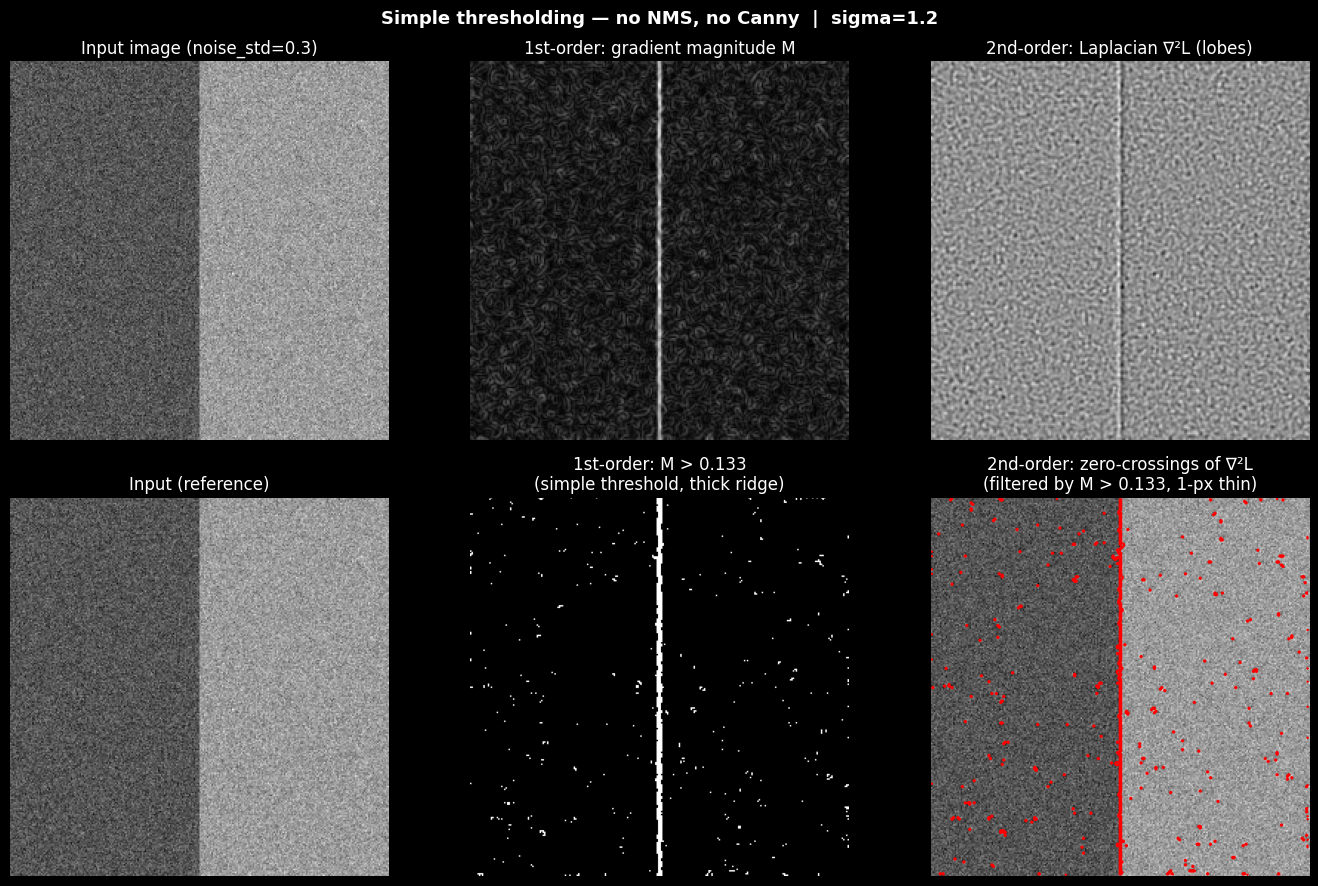

1st-order  threshold  : M > 0.1332  →  1381 edge pixels  (thick ridge)
2nd-order  zero-crossings filtered by M > 0.1332  →  625 edge pixels  (thin line)


In [3]:
# -------------------------
# Filter scale (edit this)
# -------------------------
sigma = 1.2

g, g1, g2 = gaussian_1d_kernels(sigma=sigma, radius_sigma=4.0)

# Smoothed image
L = separable_conv(I, g, g)

# First derivatives (Derivative-of-Gaussian)
Lx = separable_conv(I, g1, g)   # x-derivative kernel in x, Gaussian in y
Ly = separable_conv(I, g, g1)   # Gaussian in x, y-derivative kernel in y
M = np.sqrt(Lx**2 + Ly**2)      # gradient magnitude

# Second derivatives and Laplacian
Lxx = separable_conv(I, g2, g)
Lyy = separable_conv(I, g, g2)
Lap = Lxx + Lyy

# Zero-crossings of Laplacian (simple 4-neighborhood)
zc = zero_crossings_4nbr(Lap)

# Optional: keep only zero-crossings where gradient magnitude is strong (set to 0 to disable)
zc_strength_thresh = edge_thresh_ratio * M.max()
zc_strong = zc & (M > zc_strength_thresh)

# -------------------------------------------------------
# Simple threshold — no NMS, no Canny
# -------------------------------------------------------
# 1st-order edge map: keep pixels where gradient magnitude exceeds a fraction of its max
m_thresh = edge_thresh_ratio * M.max()
edge_1st = (M > m_thresh)

# 2nd-order edge map: zero-crossings already filtered by the same gradient threshold
# (zc_strong computed above)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# Row 0 — intermediate maps
axes[0, 0].imshow(I, cmap="gray")
axes[0, 0].set_title(f"Input image (noise_std={noise_std})")
axes[0, 0].axis("off")

axes[0, 1].imshow(M, cmap="gray")
axes[0, 1].set_title("1st-order: gradient magnitude M")
axes[0, 1].axis("off")

axes[0, 2].imshow(Lap, cmap="gray")
axes[0, 2].set_title("2nd-order: Laplacian ∇²L (lobes)")
axes[0, 2].axis("off")

# Row 1 — binary edge maps
axes[1, 0].imshow(I, cmap="gray")
axes[1, 0].set_title("Input (reference)")
axes[1, 0].axis("off")

# 1st-order: simple threshold on M  →  binary mask
axes[1, 1].imshow(edge_1st, cmap="gray")
axes[1, 1].set_title(f"1st-order: M > {m_thresh:.3f}\n(simple threshold, thick ridge)")
axes[1, 1].axis("off")

# 2nd-order: zero-crossings overlay on input
axes[1, 2].imshow(I, cmap="gray")
axes[1, 2].set_title(f"2nd-order: zero-crossings of ∇²L\n(filtered by M > {zc_strength_thresh:.3f}, 1-px thin)")
axes[1, 2].contour(zc_strong.astype(float), levels=[0.5], colors="red")
axes[1, 2].axis("off")

plt.suptitle(
    f"Simple thresholding — no NMS, no Canny  |  sigma={sigma}",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

print(f"1st-order  threshold  : M > {m_thresh:.4f}  →  {edge_1st.sum()} edge pixels  (thick ridge)")
print(f"2nd-order  zero-crossings filtered by M > {zc_strength_thresh:.4f}  →  {zc_strong.sum()} edge pixels  (thin line)")

In [4]:
# Requires these to already exist in your notebook:
#   d         : signed distance to the true edge (same shape as image)
#   edge_1st  : boolean mask from 1st-order thresholding
#   zc_strong : boolean mask from 2nd-order zero-crossings filtered by M threshold

import numpy as np
from scipy.ndimage import label
import pandas as pd

tau = 2.0      # band half-width in pixels (tolerance around the true edge)
alpha = 0.5    # overlap fraction needed to call a component "true" (TP component)

band = (np.abs(d) <= tau)

# 4-connectivity structure
STRUCT4 = np.array([[0, 1, 0],
                    [1, 1, 1],
                    [0, 1, 0]], dtype=int)

def component_metrics(mask: np.ndarray, band: np.ndarray, alpha: float = 0.5):
    lab, n = label(mask.astype(bool), structure=STRUCT4)

    if n == 0:
        return {
            "n_comp": 0,
            "tp_comp": 0,
            "fp_comp": 0,
            "tp_area": 0,
            "fp_area": 0,
            "fp_area_ratio": 0.0,
        }

    tp_comp = fp_comp = 0
    tp_area = fp_area = 0

    for cid in range(1, n + 1):
        comp = (lab == cid)
        sz = int(comp.sum())
        ov = float((comp & band).sum()) / (sz + 1e-12)  # overlap fraction with the band

        if ov >= alpha:
            tp_comp += 1
            tp_area += sz
        else:
            fp_comp += 1
            fp_area += sz

    return {
        "n_comp": n,
        "tp_comp": tp_comp,
        "fp_comp": fp_comp,
        "tp_area": tp_area,
        "fp_area": fp_area,
        "fp_area_ratio": fp_area / (tp_area + fp_area + 1e-12),
    }

m_first = component_metrics(edge_1st, band, alpha=alpha)
m_second = component_metrics(zc_strong, band, alpha=alpha)

df = pd.DataFrame([m_first, m_second], index=["1st-order (M threshold)", "2nd-order (ZC + M filter)"])
display(df)

,n_comp,tp_comp,fp_comp,tp_area,fp_area,fp_area_ratio
1st-order (M threshold),301,1,300,895,486,0.351919
2nd-order (ZC + M filter),275,21,254,300,325,0.520000


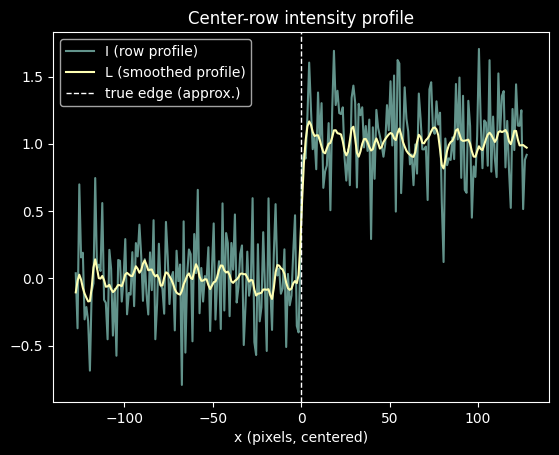

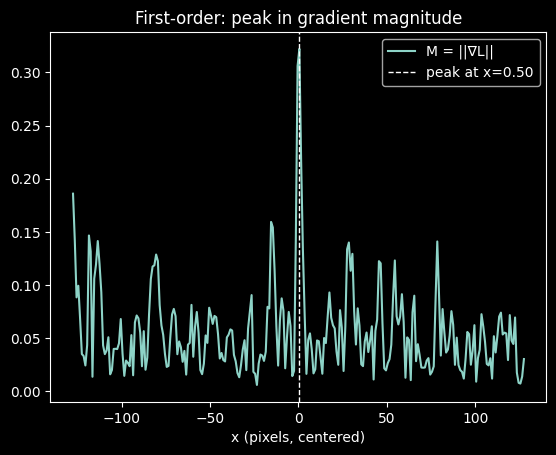

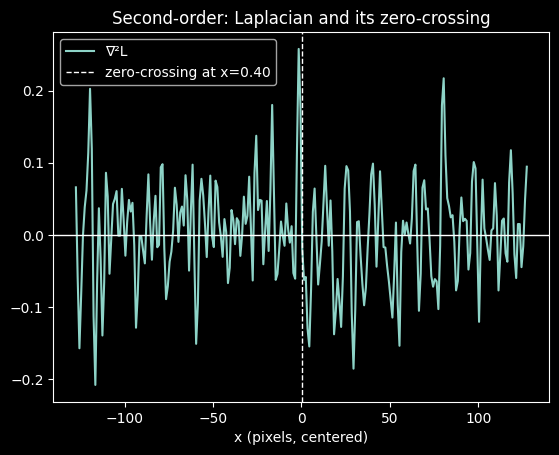

In [5]:
# Take a horizontal profile through the center row (works best when theta_deg = 0°)
row = H // 2

x_axis = np.arange(W) - (W - 1) / 2
I_prof   = I[row, :]
M_prof   = M[row, :]
Lap_prof = Lap[row, :]

# Peak in gradient magnitude along the profile
i_peak = int(np.argmax(M_prof))
x_peak = x_axis[i_peak]

# Zero-crossing in Laplacian near the peak (find sign change closest to x_peak)
sign = np.sign(Lap_prof)
zc_candidates = []
for i in range(W - 1):
    if Lap_prof[i] == 0:
        zc_candidates.append(x_axis[i])
    elif sign[i] * sign[i + 1] < 0:
        # linear interpolation
        x0 = x_axis[i] - Lap_prof[i] * (x_axis[i + 1] - x_axis[i]) / (Lap_prof[i + 1] - Lap_prof[i])
        zc_candidates.append(x0)

x_zc = min(zc_candidates, key=lambda t: abs(t - x_peak)) if zc_candidates else None

plt.figure()
plt.plot(x_axis, I_prof, label="I (row profile)", alpha=0.7)
plt.plot(x_axis, separable_conv(I, g, g)[row, :], label="L (smoothed profile)")
plt.axvline(0.0, linestyle="--", linewidth=1, label="true edge (approx.)")
plt.title("Center-row intensity profile")
plt.xlabel("x (pixels, centered)")
plt.legend()
plt.show()

plt.figure()
plt.plot(x_axis, M_prof, label="M = ||∇L||")
plt.axvline(x_peak, linestyle="--", linewidth=1, label=f"peak at x={x_peak:.2f}")
plt.title("First-order: peak in gradient magnitude")
plt.xlabel("x (pixels, centered)")
plt.legend()
plt.show()

plt.figure()
plt.plot(x_axis, Lap_prof, label="∇²L")
plt.axhline(0.0, linewidth=1)
if x_zc is not None:
    plt.axvline(x_zc, linestyle="--", linewidth=1, label=f"zero-crossing at x={x_zc:.2f}")
plt.title("Second-order: Laplacian and its zero-crossing")
plt.xlabel("x (pixels, centered)")
plt.legend()
plt.show()

# Conclusion (2D)

- After Gaussian smoothing, the **first-order** method uses the gradient magnitude
  $$M = \|\nabla L\|$$
  which forms a **ridge** near an edge. The edge location is best obtained by keeping only the ridge **maximum** (this motivates NMS).

- The **second-order** method uses the Laplacian
  $$\nabla^2 L = L_{xx}+L_{yy},$$
  which typically produces **positive/negative lobes** around a step edge, and the edge center corresponds to a **zero-crossing**.

- With noise (`noise_std > 0`), the gradient ridge becomes noisier and the Laplacian can create extra sign changes (extra zero-crossings), which is why practical pipelines add selection steps (NMS, hysteresis, thresholds).

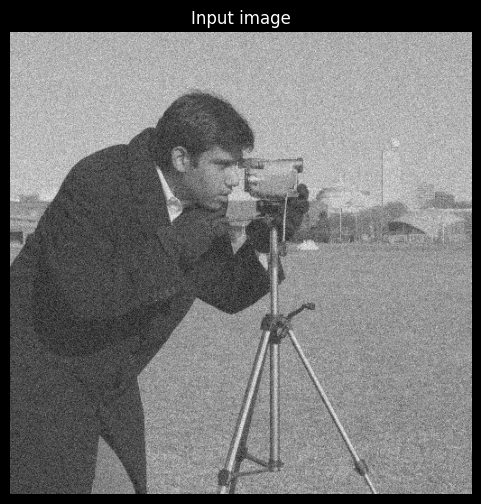

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# Real image in [0,1]
I = img_as_float(data.camera())

# Add some noise
noise_std= 0.1
I = I +  rng.normal(0.0, noise_std, size=I.shape)


# ---- parameters ----
sigma = 1.5            # smoothing scale
tM = 0.1332            # threshold on NORMALIZED gradient magnitude (0..1)

plt.figure(figsize=(6,6))
plt.imshow(I, cmap="gray")
plt.title("Input image")
plt.axis("off")
plt.show()

In [11]:
import numpy as np
from scipy import ndimage as ndi

# ---- parameters ----
sigma = 1.5
tM = 0.1332  # threshold on M_norm in [0,1]

# ---- same kernels as the notebook ----
g, g1, g2 = gaussian_1d_kernels(sigma=sigma, radius_sigma=4.0)

# ---- same scale-space fields as the notebook ----
L   = separable_conv(I, g,  g)      # smoothed image
Lx  = separable_conv(I, g1, g)      # d/dx (DoG)
Ly  = separable_conv(I, g,  g1)     # d/dy (DoG)
M   = np.hypot(Lx, Ly)
M_norm = M / (M.max() + 1e-12)

# Laplacian of the smoothed image: ΔL = Lxx + Lyy using second-derivative-of-Gaussian
Lxx = separable_conv(I, g2, g)
Lyy = separable_conv(I, g,  g2)
Lap = Lxx + Lyy

# ---- detectors (exactly what you asked: no NMS, no hysteresis) ----
edge_1st = (M_norm > tM)

mx = ndi.maximum_filter(Lap, size=3)
mn = ndi.minimum_filter(Lap, size=3)
zc = (mx > 0) & (mn < 0)

zc_thr = zc & (M_norm > tM)

print(f"1st-order threshold: M_norm > {tM}  →  {edge_1st.sum()} edge pixels")
print(f"2nd-order ZC (raw)                     →  {zc.sum()} pixels")
print(f"2nd-order ZC filtered by M_norm > {tM} →  {zc_thr.sum()} pixels")

1st-order threshold: M_norm > 0.1332  →  33675 edge pixels
2nd-order ZC (raw)                     →  216071 pixels
2nd-order ZC filtered by M_norm > 0.1332 →  24486 pixels


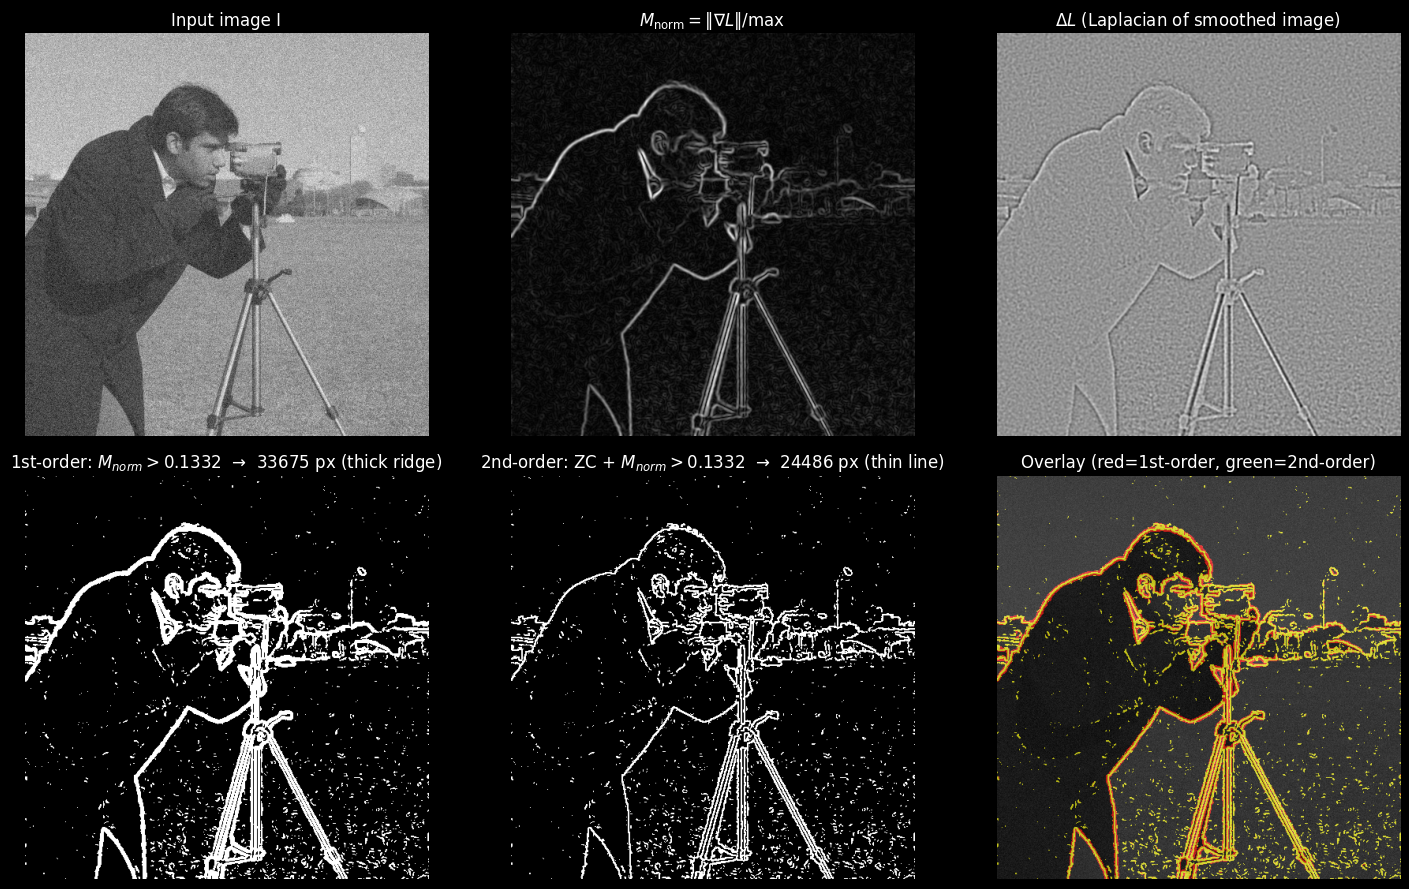

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --- counts (for titles) ---
n1 = int(edge_1st.sum())
n2 = int(zc_thr.sum())

# --- panel view (like the notebook) ---
fig, axs = plt.subplots(2, 3, figsize=(15, 9))

axs[0, 0].imshow(I, cmap="gray")
axs[0, 0].set_title("Input image I")
axs[0, 0].axis("off")

axs[0, 1].imshow(M_norm, cmap="gray")
axs[0, 1].set_title(r"$M_{\rm norm}=\|\nabla L\|/\max$")
axs[0, 1].axis("off")

axs[0, 2].imshow(Lap, cmap="gray")
axs[0, 2].set_title(r"$\Delta L$ (Laplacian of smoothed image)")
axs[0, 2].axis("off")

axs[1, 0].imshow(edge_1st, cmap="gray")
axs[1, 0].set_title(f"1st-order: $M_{{norm}}>{tM}$  →  {n1} px (thick ridge)")
axs[1, 0].axis("off")

axs[1, 1].imshow(zc_thr, cmap="gray")
axs[1, 1].set_title(f"2nd-order: ZC + $M_{{norm}}>{tM}$  →  {n2} px (thin line)")
axs[1, 1].axis("off")

# Overlay: red = 1st-order, green = 2nd-order
overlay = np.zeros((*I.shape, 3), dtype=float)
overlay[..., 0] = edge_1st.astype(float)
overlay[..., 1] = zc_thr.astype(float)

axs[1, 2].imshow(I, cmap="gray")
axs[1, 2].imshow(overlay, alpha=0.65)
axs[1, 2].set_title("Overlay (red=1st-order, green=2nd-order)")
axs[1, 2].axis("off")

plt.tight_layout()
plt.show()